In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,
confusion_matrix,ConfusionMatrixDisplay,roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Credit_dataset.csv")
df

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Debt Consolidation Loan,Home Equity Loan,Mortgage Loan,Not Specified,Payday Loan,Personal Loan,Student Loan,Debt_to_Income,EMI_to_Salary,Loans_per_History
0,23.0,19114.0,1824.843333,3,4,3,4,3,7.0,11.27,...,0,1,0,0,0,1,0,0.042323,0.027152,0.173310
1,23.0,19114.0,3093.745000,3,4,3,4,-1,14.0,11.27,...,0,1,0,0,0,1,0,0.042323,0.016019,4.000000
2,33.0,19114.0,3093.745000,3,4,3,4,3,7.0,9.40,...,0,1,0,0,0,1,0,0.042323,0.016019,0.172043
3,23.0,19114.0,3093.745000,3,4,3,4,5,4.0,6.27,...,0,1,0,0,0,1,0,0.042323,0.016019,0.171453
4,23.0,19114.0,1824.843333,3,4,3,4,6,14.0,11.27,...,0,1,0,0,0,1,0,0.042323,0.027152,0.170794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25.0,39628.0,3359.415833,4,6,7,2,23,7.0,11.50,...,0,0,0,0,0,0,1,0.012667,0.010446,0.061538
99996,25.0,39628.0,3359.415833,4,6,7,2,18,7.0,11.50,...,0,0,0,0,0,0,1,0.012667,0.010446,0.061387
99997,25.0,39628.0,3359.415833,4,6,5729,2,27,6.0,11.50,...,0,0,0,0,0,0,1,0.012667,0.010446,0.061218
99998,25.0,39628.0,3359.415833,4,6,7,2,20,14.0,11.50,...,0,0,0,0,0,0,1,0.012667,0.010446,0.061069


In [2]:
# 1. Features and target
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

# 2. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    random_state=42,
    stratify=y)


In [3]:
#Feature scaling using Standarization
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10,random_state=42)

dt.fit(X_train, y_train)   # Unscaled data

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

rf.fit(X_train, y_train)   # Unscaled data

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
y_pred_lr = lr.predict(X_test_scaled)

y_pred_dt = dt.predict(X_test)

y_pred_rf = rf.predict(X_test)

In [31]:
results = []
def evaluate_model(model_name,model,X_test, y_true, y_pred):
    print(f"\n{'='*50}")
    print(model_name)
    print('='*50)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(
        y_true,
        model.predict_proba(X_test),
        multi_class='ovr')

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

In [32]:
evaluate_model("Logistic Regression",lr,X_test_scaled, y_test, y_pred_lr)
evaluate_model("Decision Tree",dt,X_test, y_test, y_pred_dt)
evaluate_model("Random Forest",rf,X_test, y_test, y_pred_rf)


Logistic Regression
Accuracy : 0.6014
Precision: 0.5976740735987902
Recall   : 0.6014
F1 Score : 0.5829948816206827
ROC-AUC  : 0.7677237800673327

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.44      0.52      5799
           1       0.60      0.79      0.68     10635
           2       0.51      0.30      0.38      3566

    accuracy                           0.60     20000
   macro avg       0.59      0.51      0.53     20000
weighted avg       0.60      0.60      0.58     20000


Confusion Matrix:
[[2577 3054  168]
 [1412 8383  840]
 [  54 2444 1068]]

Decision Tree
Accuracy : 0.71015
Precision: 0.7138508802198489
Recall   : 0.71015
F1 Score : 0.7112695019544824
ROC-AUC  : 0.8471654926795305

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.68      0.70      5799
           1       0.75      0.75      0.75     10635
           2       0.57      0.65      0.61 

In [11]:
print("RF Train Accuracy:", rf.score(X_train, y_train))     #shows overfitting or not
print("RF Test Accuracy :", rf.score(X_test, y_test))

RF Train Accuracy: 0.9999875
RF Test Accuracy : 0.79495


In [12]:
rf_probs = rf.predict_proba(X_test)

rf_auc = roc_auc_score(
    y_test,
    rf_probs,
    multi_class='ovr')

print(rf_auc)

0.9164709200360267


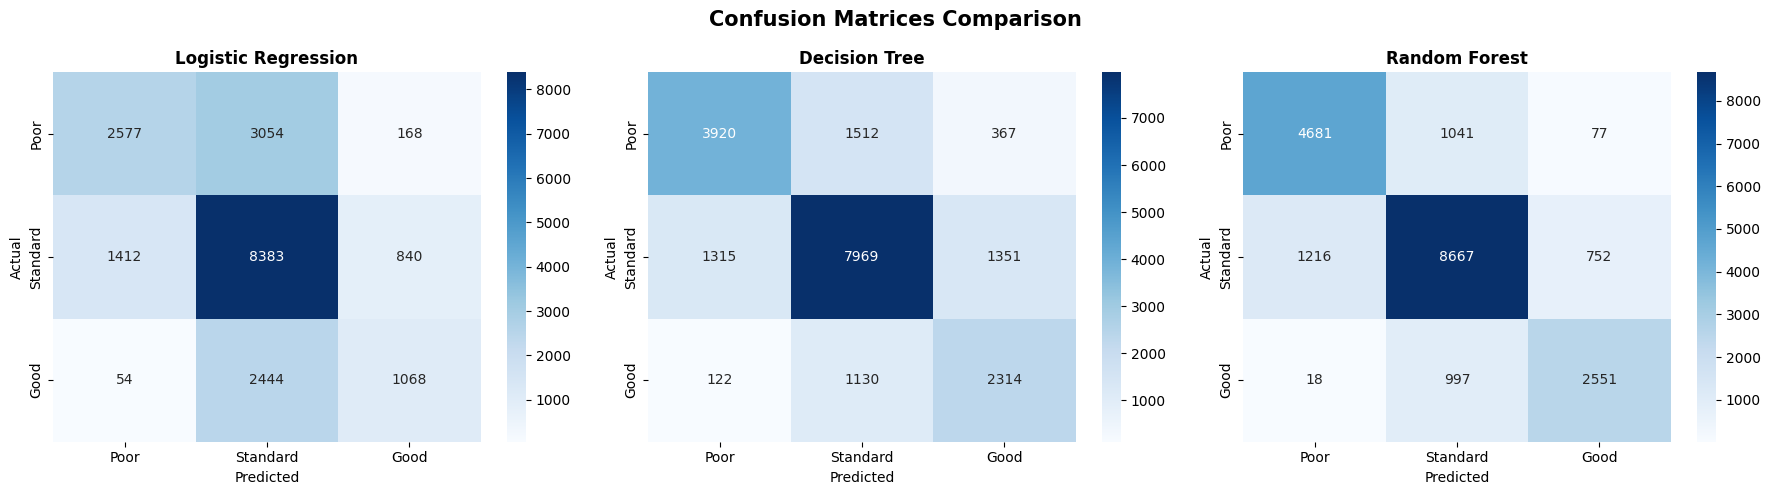

In [13]:
# Predictions
predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Poor', 'Standard', 'Good'],
        yticklabels=['Poor', 'Standard', 'Good']
    )
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(
    'Confusion Matrices Comparison',
    fontsize=15,
    fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
lr_probs = lr.predict_proba(X_test_scaled)
dt_probs = dt.predict_proba(X_test)
rf_probs = rf.predict_proba(X_test)
results = {
    'Logistic Regression': {'y_prob': lr_probs},
    'Decision Tree': {'y_prob': dt_probs},
    'Random Forest': {'y_prob': rf_probs}
}

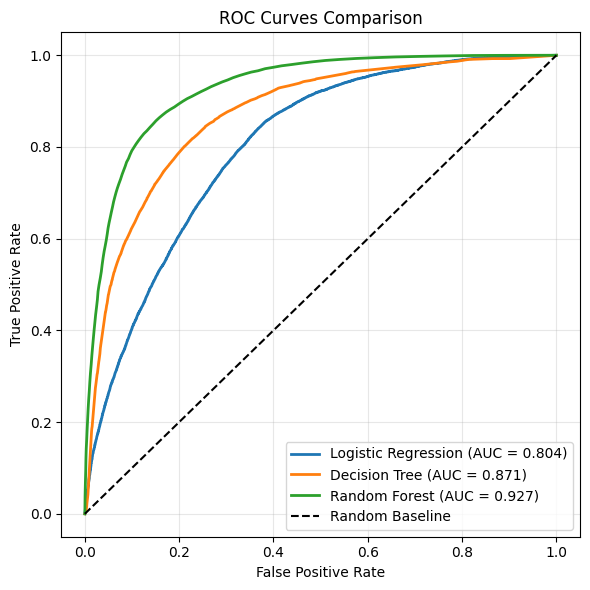

In [15]:

# Convert multiclass target to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(6, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        res['y_prob'].ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})")
    
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ROC_Curves.png', dpi=150)
plt.show()

In [38]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
importance_df.to_csv("Feature_Importance.csv", index=False)
print(importance_df.head(20))

                     Feature  Importance
12          Outstanding_Debt    0.087425
5              Interest_Rate    0.070928
7        Delay_from_due_date    0.053611
11                Credit_Mix    0.051577
9       Changed_Credit_Limit    0.049270
48            Debt_to_Income    0.045763
18      Credit_History_Years    0.045571
50         Loans_per_History    0.044111
4            Num_Credit_Card    0.037654
13  Credit_Utilization_Ratio    0.037448
10      Num_Credit_Inquiries    0.036458
8     Num_of_Delayed_Payment    0.036353
17           Monthly_Balance    0.035214
16   Amount_invested_monthly    0.034916
1              Annual_Income    0.032633
49             EMI_to_Salary    0.031267
0                        Age    0.030964
3          Num_Bank_Accounts    0.030136
2      Monthly_Inhand_Salary    0.029754
15       Total_EMI_per_month    0.028219


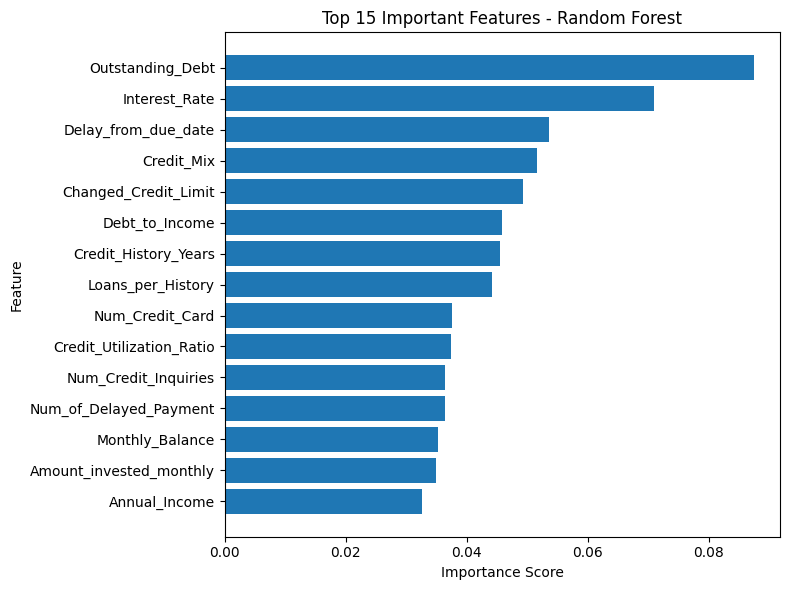

In [18]:
import matplotlib.pyplot as plt

top15 = importance_df.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top15['Feature'],
    top15['Importance']
)

plt.gca().invert_yaxis()

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Important Features - Random Forest')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [33]:
y_pred_et = et.predict(X_test)
evaluate_model("Extra Tree ", et, X_test, y_test, y_pred_et)


Extra Tree 
Accuracy : 0.79175
Precision: 0.7912692106704179
Recall   : 0.79175
F1 Score : 0.7912630345360476
ROC-AUC  : 0.9141255410388092

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79      5799
           1       0.80      0.82      0.81     10635
           2       0.76      0.71      0.73      3566

    accuracy                           0.79     20000
   macro avg       0.78      0.77      0.78     20000
weighted avg       0.79      0.79      0.79     20000


Confusion Matrix:
[[4575 1169   55]
 [1148 8736  751]
 [   8 1034 2524]]


In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,          # try 10 random combinations
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [34]:
best_rf = random_search.best_estimator_

y_preds = best_rf.predict(X_test)
evaluate_model("Tuned Random Forest ", best_rf, X_test, y_test, y_preds)


Tuned Random Forest 
Accuracy : 0.7908
Precision: 0.7904931903382045
Recall   : 0.7908
F1 Score : 0.7906203165638982
ROC-AUC  : 0.9113935781884145

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      5799
           1       0.81      0.81      0.81     10635
           2       0.74      0.72      0.73      3566

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000


Confusion Matrix:
[[4602 1078  119]
 [1184 8653  798]
 [  22  983 2561]]


In [36]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False)

print(comparison_df)

                  Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
2         Random Forest    0.7950     0.7945  0.7950    0.7946   0.9165
3           Extra Tree     0.7917     0.7913  0.7917    0.7913   0.9141
4  Tuned Random Forest     0.7908     0.7905  0.7908    0.7906   0.9114
1         Decision Tree    0.7101     0.7139  0.7101    0.7113   0.8472
0   Logistic Regression    0.6014     0.5977  0.6014    0.5830   0.7677


In [37]:
comparison_df.to_csv("Model_Comparison.csv", index=False)

In [5]:
import joblib

joblib.dump(rf, "credit_scoring_model.pkl")

['credit_scoring_model.pkl']